# Discussion 3 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup  
Load dependencies and set up environment for discussion 2. The dataset includes 'motor_UPDRS' (a sub-score) and 'total_UPDRS' (the target). If 'motor_UPDRS' is used to predict 'total_UPDRS', it is data leakage because they are mathematically linked. Thus, it must be dropped.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")

print("Downloading Parkinson's Telemonitoring dataset from UCI...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data"
df = pd.read_csv(url)

X = df.drop(columns=['subject#', 'motor_UPDRS', 'total_UPDRS'])
y = df['total_UPDRS']

print(f"Dataset loaded: {X.shape[0]} patient records and {X.shape[1]} features.")

Dataset loaded: 5875 patient records and 19 features.


## Data Summarization and Visualization  
For regression, visualizing the distribution of the target variable and correlation between features is important. There will be a histogram plot and correlation heatmap between features to show this.


--- DATA SUMMARIZATION ---
Average Total UPDRS Score: 29.02
Minimum Score: 7.00 | Maximum Score: 54.99


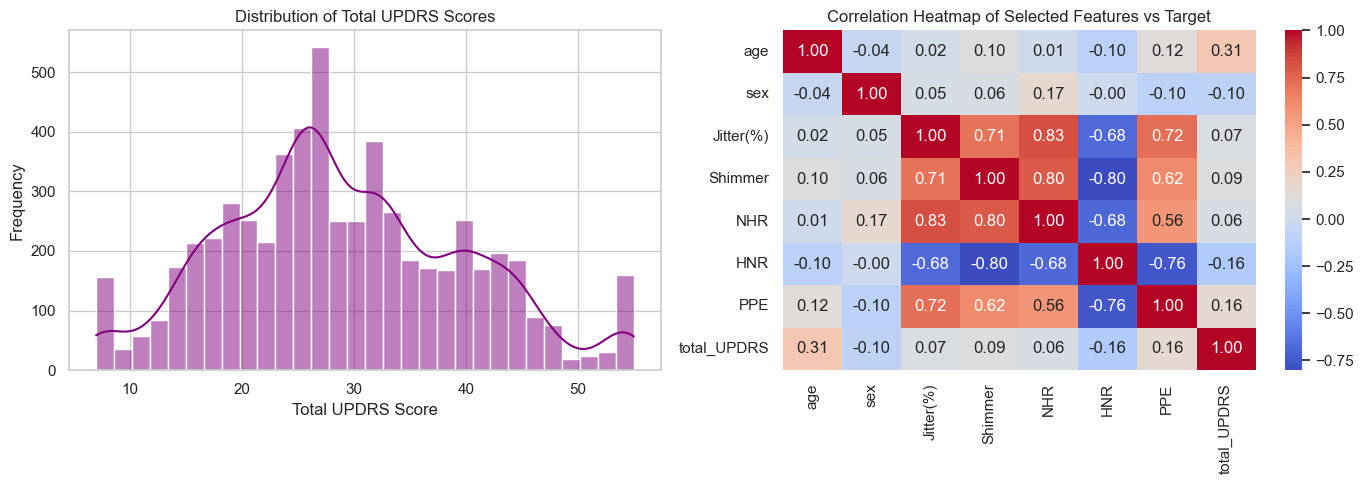

In [2]:
print("\n--- DATA SUMMARIZATION ---")
print(f"Average Total UPDRS Score: {y.mean():.2f}")
print(f"Minimum Score: {y.min():.2f} | Maximum Score: {y.max():.2f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True, color="purple")
plt.title("Distribution of Total UPDRS Scores")
plt.xlabel("Total UPDRS Score")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
subset_features = ['age', 'sex', 'Jitter(%)', 'Shimmer', 'NHR', 'HNR', 'PPE']
corr_matrix = df[subset_features + ['total_UPDRS']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Heatmap of Selected Features vs Target")

plt.tight_layout()
plt.show()